# CH 6 - Observed Performance and Expected Performance versus Number of Observations

> **Eurêka final :** dans un univers de règles à mérite variable, le champion du **backtest** est choisi à partir d’un mélange de talent réel et de chance. Sa performance observée est donc presque toujours trop optimiste par rapport à sa performance future attendue.

Ce notebook illustre la différence entre **performance observée** et **performance attendue** quand on sélectionne la meilleure règle parmi plusieurs candidates.

L’objectif est de voir visuellement pourquoi :

$$
\text{Performance observée du champion} > \text{Performance attendue du champion}
$$

et pourquoi cet écart diminue quand le nombre d’observations $N$ augmente.


## 1. Intuition EBTA

Dans une optimisation de stratégie, chaque règle possède deux composantes :

$$
P_{\text{obs}} = P_{\text{réel}} + H
$$

où :

- $P_{\text{obs}}$ est la **performance observée** dans le backtest.
- $P_{\text{réel}}$ est le **mérite réel** de la règle.
- $H$ est la part de **hasard** liée à l’échantillon historique.

Quand on choisit la meilleure règle selon $P_{\text{obs}}$, on ne choisit pas seulement la règle la plus talentueuse.

On choisit souvent celle qui a combiné :

- un certain mérite réel ;
- une chance favorable sur l’échantillon ;
- une sélection gagnante parmi plusieurs candidates.

> Le biais de minage de données est donc l’écart entre ce que le backtest promet et ce que la règle peut raisonnablement produire ensuite.


## 2. Modèle mathématique simplifié

On suppose un univers de $M$ règles.

Chaque règle $i$ possède un mérite réel :

$$
\mu_i \sim \mathcal{N}(\mu_0, \sigma_{\mu})
$$

La performance observée sur $N$ observations est :

$$
\hat{\mu}_i = \mu_i + \epsilon_i
$$

avec :

$$
\epsilon_i \sim \mathcal{N}\left(0, \frac{\sigma}{\sqrt{N}}\right)
$$

Plus $N$ est petit, plus le bruit $\epsilon_i$ est large.

Plus $N$ est grand, plus le bruit se contracte.

La règle sélectionnée est :

$$
i^* = \arg\max_i \hat{\mu}_i
$$

Le biais est :

$$
\text{Biais} = \hat{\mu}_{i^*} - \mu_{i^*}
$$

Autrement dit :

> **Biais = performance du champion dans le backtest − performance réelle attendue du même champion.**


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def simulate_observed_vs_expected(
    n_observations_list,
    n_rules=100,
    n_experiments=5000,
    true_mean=0.00,
    merit_dispersion=0.03,
    observation_noise=0.20
):
    """
    Simule un univers de règles à mérite variable.

    Pour chaque expérience :
    - on génère un mérite réel pour chaque règle ;
    - on génère une performance observée bruitée ;
    - on sélectionne la règle gagnante selon la performance observée ;
    - on mesure la performance observée du champion ;
    - on mesure son mérite réel, donc sa performance attendue future.

    Les rendements sont exprimés ici en unités abstraites.
    Par exemple, 0.05 peut être lu comme 5% moyen annualisé si on calibre ainsi le modèle.
    """
    rows = []

    for n_obs in n_observations_list:
        champion_observed = []
        champion_expected = []

        sampling_noise = observation_noise / np.sqrt(n_obs)

        for _ in range(n_experiments):
            true_merits = np.random.normal(
                loc=true_mean,
                scale=merit_dispersion,
                size=n_rules
            )

            observed_performances = true_merits + np.random.normal(
                loc=0,
                scale=sampling_noise,
                size=n_rules
            )

            winner_idx = np.argmax(observed_performances)

            champion_observed.append(observed_performances[winner_idx])
            champion_expected.append(true_merits[winner_idx])

        avg_observed = np.mean(champion_observed)
        avg_expected = np.mean(champion_expected)
        bias = avg_observed - avg_expected

        rows.append({
            "N observations": n_obs,
            "Nombre de règles": n_rules,
            "Performance observée moyenne du champion": avg_observed,
            "Performance attendue moyenne du champion": avg_expected,
            "Biais de minage": bias
        })

    return pd.DataFrame(rows)


n_observations = [2, 5, 10, 20, 50, 100, 200, 500, 1000]

df_10 = simulate_observed_vs_expected(n_observations, n_rules=10)
df_500 = simulate_observed_vs_expected(n_observations, n_rules=500)

df_results = pd.concat([df_10, df_500], ignore_index=True)
df_results

,N observations,Nombre de règles,Performance observée moyenne du champion,Performance attendue moyenne du champion,Biais de minage
0,2,10,0.223503,0.009514,0.213989
1,5,10,0.144373,0.014431,0.129942
2,10,10,0.107076,0.019863,0.087212
3,20,10,0.083980,0.026075,0.057905
4,50,10,0.063214,0.033791,0.029423
5,100,10,0.056064,0.038917,0.017147
6,200,10,0.051811,0.042453,0.009358
7,500,10,0.047995,0.044137,0.003858
8,1000,10,0.046895,0.044816,0.002080
9,2,500,0.438539,0.019173,0.419366


## 3. Lecture du tableau

Le tableau compare deux univers :

- un petit univers de **10 règles** ;
- un grand univers de **500 règles**.

Dans chaque cas, on observe trois grandeurs :

| Mesure | Signification |
|---|---|
| **Performance observée moyenne du champion** | Ce que le meilleur backtest affiche |
| **Performance attendue moyenne du champion** | Ce que le champion vaut réellement en espérance |
| **Biais de minage** | L’écart entre le rêve du backtest et la réalité attendue |

L’idée centrale est que le champion sélectionné par optimisation est rarement un pur champion de talent.

Il est souvent un champion de **talent + chance**.


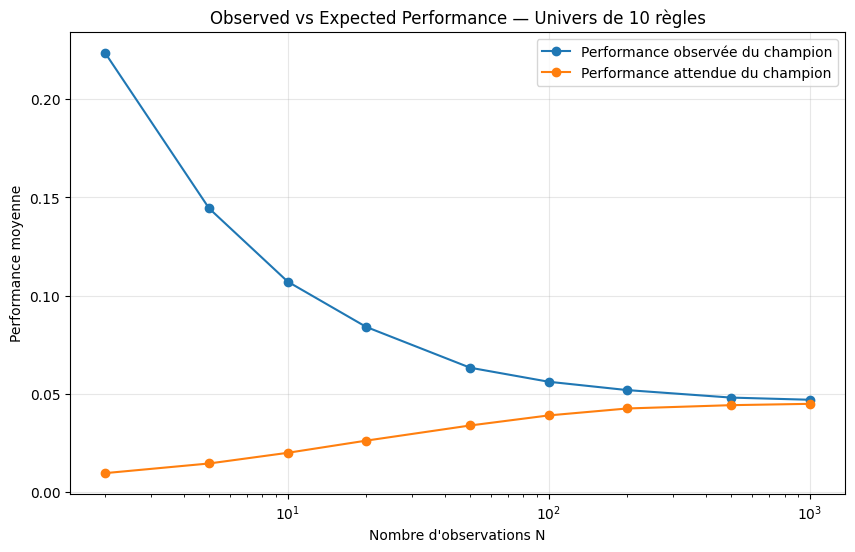

In [33]:
def plot_observed_vs_expected(df, n_rules):
    subset = df[df["Nombre de règles"] == n_rules].copy()

    plt.figure(figsize=(10, 6))

    plt.plot(
        subset["N observations"],
        subset["Performance observée moyenne du champion"],
        marker="o",
        label="Performance observée du champion"
    )

    plt.plot(
        subset["N observations"],
        subset["Performance attendue moyenne du champion"],
        marker="o",
        label="Performance attendue du champion"
    )

    plt.xscale("log")
    plt.xlabel("Nombre d'observations N")
    plt.ylabel("Performance moyenne")
    plt.title(f"Observed vs Expected Performance — Univers de {n_rules} règles")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_observed_vs_expected(df_results, n_rules=10)

## 4. Petit univers : 10 règles

Dans un univers de **10 règles**, le biais existe déjà.

Mais l’opportunité de tomber sur une règle extrêmement chanceuse est limitée.

Quand $N$ augmente :

$$
\frac{\sigma}{\sqrt{N}} \downarrow
$$

Donc le bruit d’échantillonnage diminue.

La performance observée du champion se rapproche progressivement de sa performance attendue.

> Plus l’historique est long, moins la chance peut se déguiser en talent.


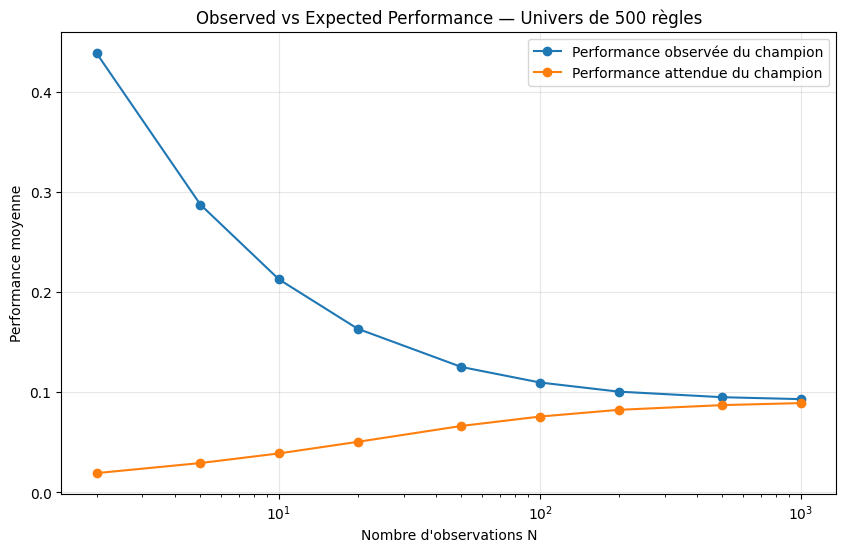

In [34]:
plot_observed_vs_expected(df_results, n_rules=500)

## 5. Grand univers : 500 règles

Dans un univers de **500 règles**, le mécanisme devient plus dangereux.

Pourquoi ?

Parce qu’avec plus de règles, on donne plus d’occasions au hasard de produire un score extrême.

Même si la majorité des règles n’ont qu’un mérite moyen, l’une d’elles peut avoir :

- un mérite réel correct ;
- une série historique très favorable ;
- un bruit positif exceptionnel.

Cette règle gagne alors la compétition du backtest.

Mais sa performance future attendue reste inférieure à son score historique.

> Tester plus de règles augmente la probabilité de sélectionner un gagnant contaminé par la chance.


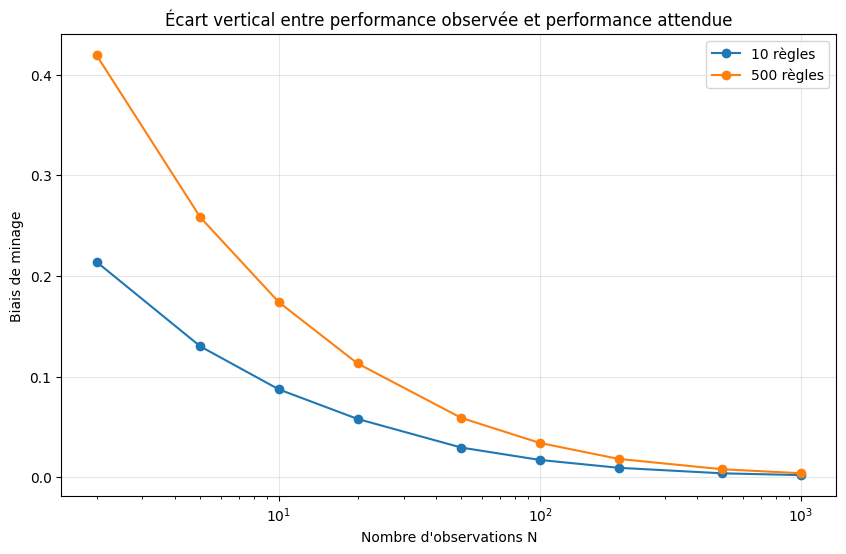

In [35]:
def plot_bias(df):
    plt.figure(figsize=(10, 6))

    for n_rules in sorted(df["Nombre de règles"].unique()):
        subset = df[df["Nombre de règles"] == n_rules]
        plt.plot(
            subset["N observations"],
            subset["Biais de minage"],
            marker="o",
            label=f"{n_rules} règles"
        )

    plt.xscale("log")
    plt.xlabel("Nombre d'observations N")
    plt.ylabel("Biais de minage")
    plt.title("Écart vertical entre performance observée et performance attendue")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_bias(df_results)

## 6. Le biais comme distance verticale

Le graphique précédent représente directement :

$$
\text{Biais} = \hat{\mu}_{i^*} - \mu_{i^*}
$$

C’est la distance verticale entre les deux courbes.

Elle est forte quand :

- $N$ est faible ;
- le nombre de règles testées est élevé ;
- le bruit de performance est important ;
- les règles sont nombreuses et suffisamment différentes.

Elle diminue quand :

- $N$ augmente ;
- la chance est diluée ;
- les performances observées convergent vers les mérites réels.

> Le temps statistique est l’ennemi du mensonge. Plus $N$ augmente, plus la chance perd sa capacité à se faire passer pour du talent.


In [36]:
# Regardons les résultats sous forme plus lisible en pourcentage.

df_percent = df_results.copy()

for col in [
    "Performance observée moyenne du champion",
    "Performance attendue moyenne du champion",
    "Biais de minage"
]:
    df_percent[col] = (100 * df_percent[col]).round(2)

df_percent

,N observations,Nombre de règles,Performance observée moyenne du champion,Performance attendue moyenne du champion,Biais de minage
0,2,10,22.35,0.95,21.40
1,5,10,14.44,1.44,12.99
2,10,10,10.71,1.99,8.72
3,20,10,8.40,2.61,5.79
4,50,10,6.32,3.38,2.94
5,100,10,5.61,3.89,1.71
6,200,10,5.18,4.25,0.94
7,500,10,4.80,4.41,0.39
8,1000,10,4.69,4.48,0.21
9,2,500,43.85,1.92,41.94


## 7. Interprétation trading

Supposons que tu optimises 500 variantes d’une stratégie :

- différents paramètres d’entrée ;
- différents stop-loss ;
- différents take-profit ;
- différents filtres horaires ;
- différents filtres de volatilité.

Tu obtiens un champion avec un très beau backtest.

La question EBTA n’est pas :

> “Est-ce que ce backtest est bon ?”

La vraie question est :

> “Quelle part de ce backtest vient du mérite réel, et quelle part vient du fait que j’ai choisi le meilleur score après avoir testé beaucoup de variantes ?”

Dans une logique de trading algorithmique, la performance brute du champion doit donc être décotée.

Une estimation plus honnête serait :

$$
\text{Performance future estimée} \approx \text{Performance backtestée} - \text{Biais estimé}
$$


## 8. Mini-exemple concret

Imagine deux situations.

| Situation | Nombre de règles testées | Nombre d’observations | Risque de biais |
|---|---:|---:|---|
| Backtest simple | 10 | 1 000 | Faible à modéré |
| Optimisation massive | 500 | 20 | Très élevé |
| Recherche large mais historique profond | 500 | 1 000 | Modéré |
| Recherche étroite et historique court | 10 | 20 | Élevé |

Ce tableau donne l’intuition :

- **beaucoup de règles + peu d’observations** = danger maximal ;
- **peu de règles + beaucoup d’observations** = situation plus saine ;
- **beaucoup de règles + beaucoup d’observations** = possible, mais exige une vraie correction statistique.

> Le problème n’est pas de chercher. Le problème est de croire naïvement le meilleur résultat trouvé.


In [54]:
def simulate_single_optimization(
    n_rules=500,
    n_obs=20,
    true_mean=0.00,
    merit_dispersion=0.03,
    observation_noise=0.20,
    seed=7
):
    np.random.seed(seed)

    true_merits = np.random.normal(true_mean, merit_dispersion, n_rules)
    observed = true_merits + np.random.normal(0, observation_noise / np.sqrt(n_obs), n_rules)

    winner_idx = np.argmax(observed)

    summary = pd.DataFrame({
        "Règle": np.arange(n_rules),
        "Mérite réel": true_merits,
        "Performance observée": observed
    })

    return summary, winner_idx


single_df, winner = simulate_single_optimization()

print("Règle gagnante :", winner)
print("Performance observée du champion :", round(single_df.loc[winner, "Performance observée"] * 100, 2), "%")
print("Performance attendue réelle du champion :", round(single_df.loc[winner, "Mérite réel"] * 100, 2), "%")
print("Biais sur cette optimisation :", round((single_df.loc[winner, "Performance observée"] - single_df.loc[winner, "Mérite réel"]) * 100, 2), "%")

single_df.sort_values("Performance observée", ascending=False).head(10)

Règle gagnante : 399
Performance observée du champion : 14.84 %
Performance attendue réelle du champion : 3.24 %
Biais sur cette optimisation : 11.6 %


,Règle,Mérite réel,Performance observée
399,399,0.032386,0.148422
162,162,0.055802,0.128241
456,456,0.057058,0.126719
158,158,0.036188,0.123687
88,88,0.045887,0.119854
316,316,0.085832,0.119832
0,0,0.050716,0.118901
442,442,0.065459,0.113210
360,360,0.018799,0.112418
154,154,0.032758,0.104847


## 9. Visualiser le champion contaminé par la chance

Le graphique suivant affiche :

- chaque règle comme un point ;
- son **mérite réel** ;
- sa **performance observée** ;
- le champion choisi par le backtest.

Cela montre pourquoi le gagnant historique n’est pas forcément celui qui a le meilleur mérite réel.


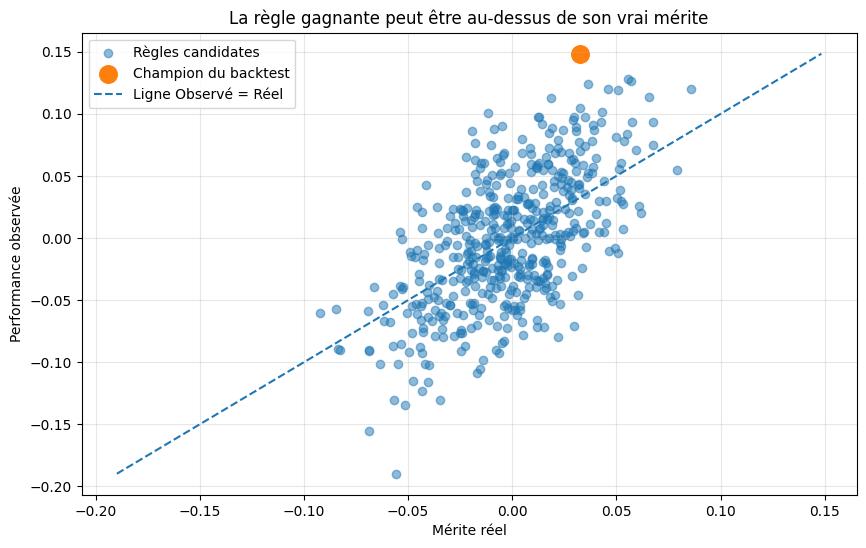

In [55]:
plt.figure(figsize=(10, 6))

plt.scatter(
    single_df["Mérite réel"],
    single_df["Performance observée"],
    alpha=0.5,
    label="Règles candidates"
)

plt.scatter(
    single_df.loc[winner, "Mérite réel"],
    single_df.loc[winner, "Performance observée"],
    s=160,
    label="Champion du backtest"
)

min_val = min(single_df["Mérite réel"].min(), single_df["Performance observée"].min())
max_val = max(single_df["Mérite réel"].max(), single_df["Performance observée"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    label="Ligne Observé = Réel"
)

plt.xlabel("Mérite réel")
plt.ylabel("Performance observée")
plt.title("La règle gagnante peut être au-dessus de son vrai mérite")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Checklist EBTA pour tes futurs backtests

Avant de croire un champion de backtest, pose ces questions :

| Question | Pourquoi c’est important |
|---|---|
| Combien de variantes ai-je testées ? | Plus $M$ est grand, plus le biais potentiel augmente |
| Combien d’observations ai-je utilisées ? | Plus $N$ est petit, plus la chance domine |
| Le champion est-il très supérieur aux autres ? | Un écart énorme peut signaler une chance extrême |
| Ai-je gardé un vrai out-of-sample ? | Il faut tester la persistance hors optimisation |
| Ai-je corrigé pour comparaisons multiples ? | Sinon, la p-value brute est trop optimiste |
| Le résultat survit-il au walk-forward ? | Une stratégie robuste doit tenir sur plusieurs fenêtres |
| Ai-je testé la sensibilité aux paramètres ? | Un edge réel ne doit pas dépendre d’un paramètre magique |

> Une stratégie n’est pas validée parce qu’elle a gagné une optimisation. Elle commence à devenir crédible quand elle survit à la décote, à l’out-of-sample et à la stabilité paramétrique.


## 11. L’Eurêka final

> **Observed > Expected** n’est pas une anomalie. C’est la conséquence normale d’un processus de sélection où le hasard joue un rôle.

Le backtest optimisé est une photo embellie du passé.

La performance attendue est une estimation plus honnête du futur.

La mission du quant n’est donc pas de trouver le plus beau backtest.

La mission du quant est de mesurer combien de beauté vient du talent réel et combien vient de la chance.

En formule simple :

$$
\text{Backtest brut} = \text{Edge réel} + \text{Chance sélectionnée}
$$

Donc :

$$
\text{Edge estimé} = \text{Backtest brut} - \text{Biais de minage}
$$

> **La discipline EBTA consiste à refuser de confondre un champion statistique avec un véritable edge.**


## 12. Annexe — Texte source fourni

### **CH 6 : OBSERVED PERFORMANCE AND EXPECTED PERFORMANCE VERSUS NUMBER OF OBSERVATIONS IN A UNIVERSE OF VARIABLE MERIT**

Cette section analyse l'écart entre la performance qu'un trader observe dans son backtest et la performance réelle qu'il peut attendre dans le futur, en fonction du volume de données disponibles.

#### **Idées clés :**
*   **Structure des courbes :** La performance observée (backtest) se situe systématiquement au-dessus de la performance attendue (réelle).
*   **Le biais comme écart :** La distance verticale entre ces deux mesures représente mathématiquement le biais de minage de données.
*   **Force de la convergence :** À mesure que le nombre d'observations augmente, les deux performances convergent, réduisant ainsi l'ampleur du mensonge statistique.
*   **Taille de l'univers :** Un univers de recherche plus vaste (ex: 500 règles contre 10) augmente l'opportunité pour la chance de creuser cet écart.

#### **Référence :**
*Observed Performance and Expected Performance versus Number of Observations in a Universe of Variable Merit*, Chapitre 6, pages 316 à 317.

#### **Citation Directe :**
« The curve of observed performance will always lie above the curve of expected performance because a best-of-selection criterion will always induce some positive bias when luck plays a role in observed performance. » (Page 318).

#### **Vision Macro :**
L'enjeu est l'intégrité de l'estimation du profit futur pour le trader. David Aronson explique que le processus de sélection de la "meilleure" règle n'est pas un acte de mesure neutre, mais un mécanisme qui favorise structurellement l'optimisme. Même avec une quantité massive de données, le profit affiché par le "champion" d'une optimisation restera toujours un indicateur biaisé à la hausse par rapport à la réalité future.

#### **Vision Micro :**
Le mécanisme de distorsion entre l'observation et l'attente se décompose ainsi :

1.  **L'asymétrie initiale (Figures 6.53 & 6.54) :** Sur un échantillon très court (à gauche des graphiques), le hasard domine totalement le mérite réel. La performance observée est alors démesurément plus élevée que l'espérance de gain réelle.
2.  **L'action de la Loi des Grands Nombres :** À mesure que l'on avance vers 1 000 mois d'observations, la distribution de performance se resserre. La part de chance "diluée" permet à la performance observée de se rapprocher de la vérité du pouvoir prédictif.
3.  **L'impact de l'exploration :** En comparant les Figures 6.53 (10 règles) et 6.54 (500 règles), on constate que le biais est plus prononcé dans le second cas. Plus le chercheur ratisse large, plus il a de chances de tomber sur une règle dont la performance est dopée par une coïncidence heureuse avec les données historiques.

#### **Résumé Simplifié :**
Imaginez que vous cherchiez la meilleure équipe de football sur un seul match (échantillon court). Le gagnant aura un score magnifique, mais il ne reflète pas son niveau réel car il a pu gagner par chance. Si vous les regardez jouer 1 000 matchs (échantillon large), le score du champion sera beaucoup plus proche de son talent réel, même s'il reste légèrement gonflé par le fait que vous avez spécifiquement choisi celui qui a fini premier.

#### **Actions Concrètes :**
*   **Appliquer une décote systématique :** Ne basez jamais vos attentes de profit sur le chiffre brut de votre backtest optimisé, car il contient toujours une part de chance non récurrente.
*   **Privilégier la profondeur des données :** Avant d'augmenter la complexité de votre univers de recherche, assurez-vous d'augmenter le nombre d'observations pour forcer la convergence des courbes.
*   **Évaluer l'écart relatif :** Si le profit observé est massivement supérieur à la moyenne de l'univers, soyez d'autant plus sceptique quant à sa persistance hors-échantillon.

#### **À retenir absolument :**
*   **Observed > Expected** : Le backtest est toujours plus beau que le futur.
*   Le **biais de minage** est l'écart vertical entre ces deux valeurs.
*   Le **temps (N)** est le seul facteur qui fait converger le mensonge vers la vérité.
*   Tester **plus de règles** augmente mécaniquement cet écart.
*   La performance réelle est une **chute inévitable** depuis une attente irréaliste.

J'ai terminé l'analyse de la relation entre performance observée et attendue selon le protocole EBTA.